# Notebook 03 - Análisis Exploratorio de Datos (EDA)

**Proyecto Integrador - Minería de Datos I - Tec. Sup. Ciencia de Datos - ITSE**  
**Integrante: Daniela Fernández - Julio Nahuel Gomez**

**Dataset:** Usuarios de plataforma de streaming  
**Objetivo:** Explorar el dataset limpio mediante análisis univariado, bivariado y multivariado, respondiendo las siguientes preguntas:

1. ¿Cómo se distribuyen los usuarios por plan de suscripción?
2. ¿Cómo es la distribución de edades de los usuarios?
3. ¿Qué géneros son los más populares?
4. ¿Los usuarios con plan Premium ven más contenido que los de otros planes?
5. ¿Existe relación entre la edad y el tiempo de visualización?
6. ¿Cuál es el género favorito según el país?
7. ¿La edad y el tiempo de visualización varían según el plan de suscripción?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el dataset limpio desde el repositorio GitHub
df = pd.read_csv('https://raw.githubusercontent.com/Danielafz/PI_Mineria_Datos_I/main/data/processed/streaming_users_clean.csv')
df['last_login_date'] = pd.to_datetime(df['last_login_date'])

print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

Dataset cargado: 7003 filas, 8 columnas


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39,Estándar,805.8,Brasil,Crimen,2025-03-04,99
1,10001,37,Estándar,1173.4,Colombia,Crimen,2019-04-02,2
2,10002,28,Básico,401.0,Colombia,Crimen,2018-04-13,0
3,10003,43,Básico,62.4,Uruguay,Thriller,2021-01-31,0
4,10004,51,Básico,477.8,Perú,Thriller,2020-09-30,1


# **Análisis Univariado**

El análisis univariado estudia cada variable de forma independiente para entender su distribución y comportamiento.

# PREGUNTA #1 **¿CÓMO SE DISTRIBUYEN LOS USUARIOS POR PLAN DE SUSCRIPCIÓN?**

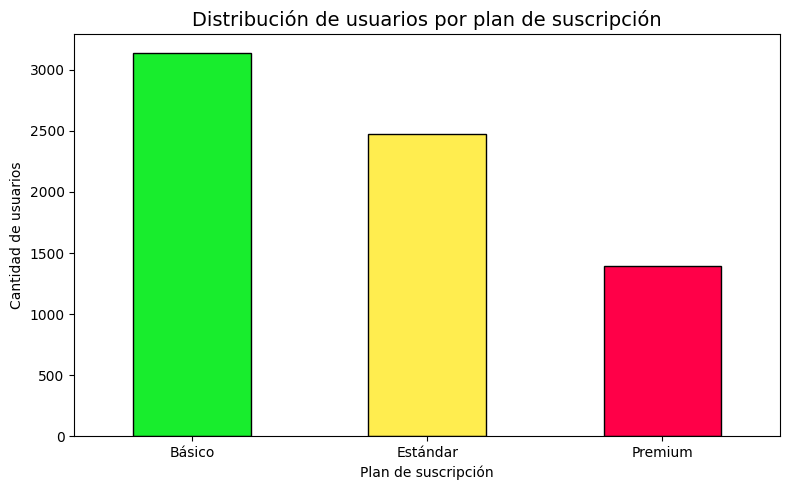

subscription_plan
Básico      3134
Estándar    2476
Premium     1393
Name: count, dtype: int64

Porcentajes:
subscription_plan
Básico      44.75
Estándar    35.36
Premium     19.89
Name: count, dtype: float64


In [9]:

conteo_planes = df['subscription_plan'].value_counts()

plt.figure(figsize=(8, 5))
colores = ['#18ed2d', '#ffed4f', '#ff0048']
conteo_planes.plot(kind='bar', color=colores, edgecolor='black')
plt.title('Distribución de usuarios por plan de suscripción', fontsize=14)
plt.xlabel('Plan de suscripción')
plt.ylabel('Cantidad de usuarios')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(conteo_planes)
print(f"\nPorcentajes:")
print(round(conteo_planes / conteo_planes.sum() * 100, 2))

La mayoría de los usuarios (44.75%) tiene el plan Básico, seguido por el Estándar (35.36%) y finalmente Premium (19.89%). Esto sugiere que la plataforma tiene una base de usuarios orientada a planes económicos, con menos de un quinto de los usuarios dispuestos a pagar el plan más caro.

# Pregunta #2 **¿Cómo es la distribución de edades de los usuarios?**

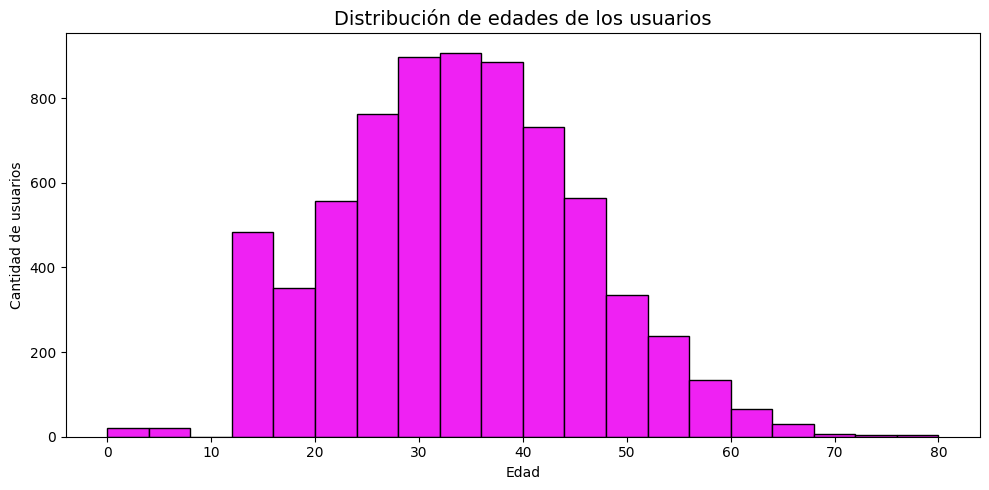

Media de edad: 33.4 años
Mediana de edad: 33.0 años
Edad mínima: 0 años
Edad máxima: 80 años


In [5]:
plt.figure(figsize=(10, 5))
plt.hist(df['age'], bins=20, color='#ef21f3', edgecolor='black')
plt.title('Distribución de edades de los usuarios', fontsize=14)
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.tight_layout()
plt.show()

print(f"Media de edad: {df['age'].mean():.1f} años")
print(f"Mediana de edad: {df['age'].median():.1f} años")
print(f"Edad mínima: {df['age'].min()} años")
print(f"Edad máxima: {df['age'].max()} años")

La distribución de edades muestra una concentración principal entre los 25 y 45 años, con una media de 33.4 años y mediana de 33 años. La distribución es aproximadamente simétrica con una leve cola hacia la derecha, lo que indica que la plataforma es utilizada principalmente por adultos jóvenes y de mediana edad.

# Pregunta #3 **¿Qué géneros son los más populares?**

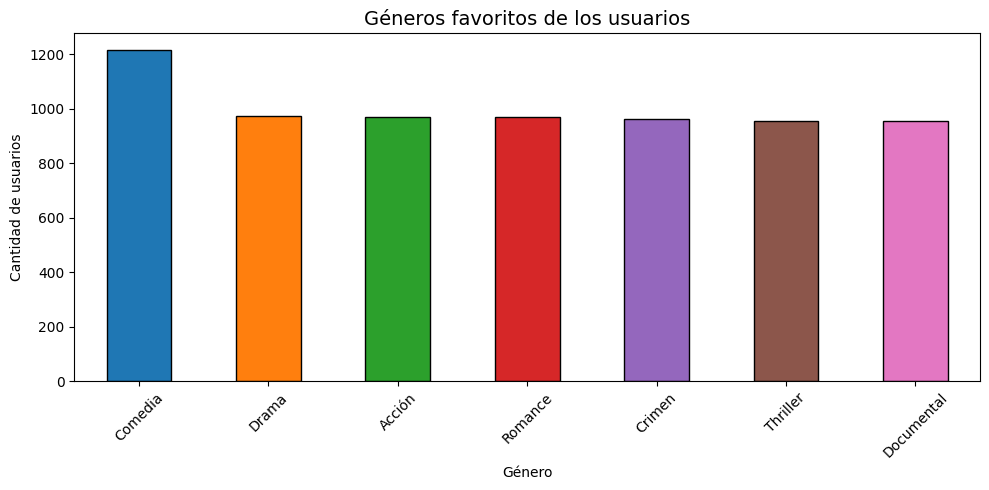

favorite_genre
Comedia       1216
Drama          974
Acción         971
Romance        971
Crimen         962
Thriller       955
Documental     954
Name: count, dtype: int64

Porcentajes:
favorite_genre
Comedia       17.36
Drama         13.91
Acción        13.87
Romance       13.87
Crimen        13.74
Thriller      13.64
Documental    13.62
Name: count, dtype: float64


In [14]:
conteo_generos = df['favorite_genre'].value_counts()

plt.figure(figsize=(10, 5))
conteo_generos.plot(kind='bar', color=plt.cm.tab10.colors, edgecolor='black')
plt.title('Géneros favoritos de los usuarios', fontsize=14)
plt.xlabel('Género')
plt.ylabel('Cantidad de usuarios')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(conteo_generos)
print(f"\nPorcentajes:")

print(round(conteo_generos / conteo_generos.sum() * 100, 2))

En este gráfico observamos que:

* Los géneros favoritos están distribuidos de forma bastante homogénea entre los usuarios.

* **Comedia** es el más popular con un 17.36%, seguido por **Drama** (13.91%) y **Acción** (13.87%).
* **Documental** es el menos elegido con 13.62%.

* La distribución pareja sugiere que la plataforma tiene una audiencia con gustos variados y no hay un género dominante muy marcado.

# **Análisis Bivariado**

El análisis bivariado estudia la relación entre dos variables para identificar patrones o asociaciones.

# Pregunta #4 **¿Los usuarios con plan Premium ven más contenido que los de otros planes?**


/tmp/ipykernel_3307/3695532440.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='subscription_plan', y='monthly_watch_time_mins',


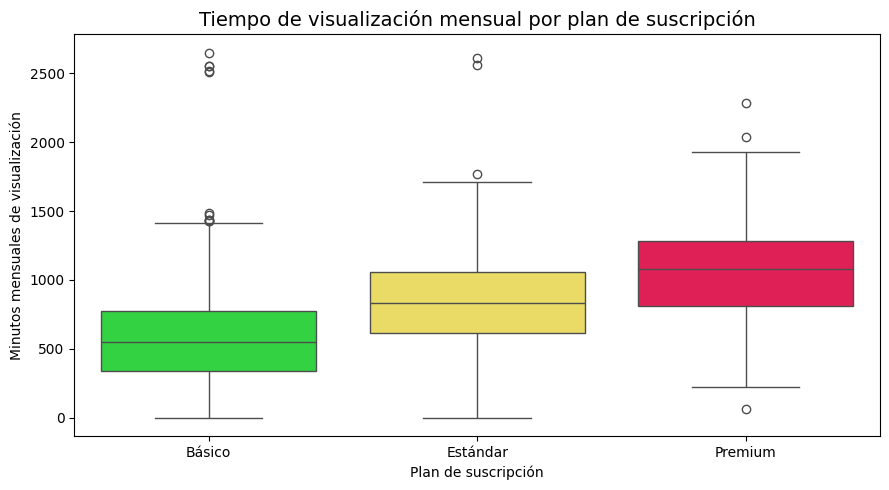

subscription_plan
Básico       551.90
Estándar     830.95
Premium     1080.80
Name: monthly_watch_time_mins, dtype: float64


In [19]:
# En este caso usamos boxplot que es un gráfico que muestra la distribución de una variable numérica.
#La línea del medio es la mediana, la caja abarca el 50% central de los datos y los puntos fuera son outliers.


plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='subscription_plan', y='monthly_watch_time_mins',
            palette=['#18ed2d', '#ffed4f', '#ff0048'],
            order=['Básico', 'Estándar', 'Premium'])
plt.title('Tiempo de visualización mensual por plan de suscripción', fontsize=14)
plt.xlabel('Plan de suscripción')
plt.ylabel('Minutos mensuales de visualización')
plt.tight_layout()
plt.show()

print(df.groupby('subscription_plan')['monthly_watch_time_mins'].median())

El gráfico muestra una diferencia clara en el tiempo de visualización según el plan. Los usuarios Premium tienen una mediana de 1088.88 minutos mensuales, casi el doble que los usuarios Básico (551.90 minutos) y significativamente más que los Estándar (838.95 minutos). Esto confirma que existe una relación entre el plan contratado y el consumo de contenido: a mayor inversión en el plan, mayor uso de la plataforma.

# Pregunta #5 **¿Existe relación entre la edad y el tiempo de visualización?**

El coeficiente de correlación es un número entre -1 y 1 que indica qué tan relacionadas están dos variables. Si es cercano a 0 no hay relación, cercano a 1 hay relación positiva y cercano a -1 hay relación negativa.

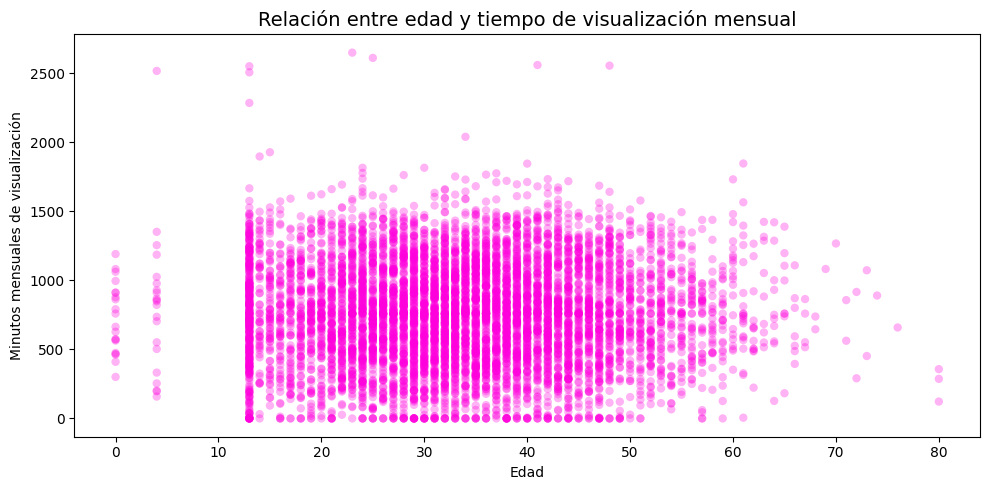

Coeficiente de correlación: 0.003


In [17]:
plt.figure(figsize=(10, 5))
plt.scatter(df['age'], df['monthly_watch_time_mins'],
            alpha=0.3, color='#ff00dd', edgecolors='none')
plt.title('Relación entre edad y tiempo de visualización mensual', fontsize=14)
plt.xlabel('Edad')
plt.ylabel('Minutos mensuales de visualización')
plt.tight_layout()
plt.show()

correlacion = df['age'].corr(df['monthly_watch_time_mins'])
print(f"Coeficiente de correlación: {correlacion:.3f}")

El gráfico de dispersión muestra que no existe relación entre la edad del usuario y el tiempo de visualización mensual. El coeficiente de correlación de 0.003 confirma esta observación, siendo prácticamente cero. Esto indica que el consumo de contenido en la plataforma es independiente de la edad del usuario, y que otros factores como el plan de suscripción tienen mayor influencia en el tiempo de visualización.

# Pregunta #6 **¿Cuál es el género favorito según el país?**

<Figure size 1200x600 with 0 Axes>

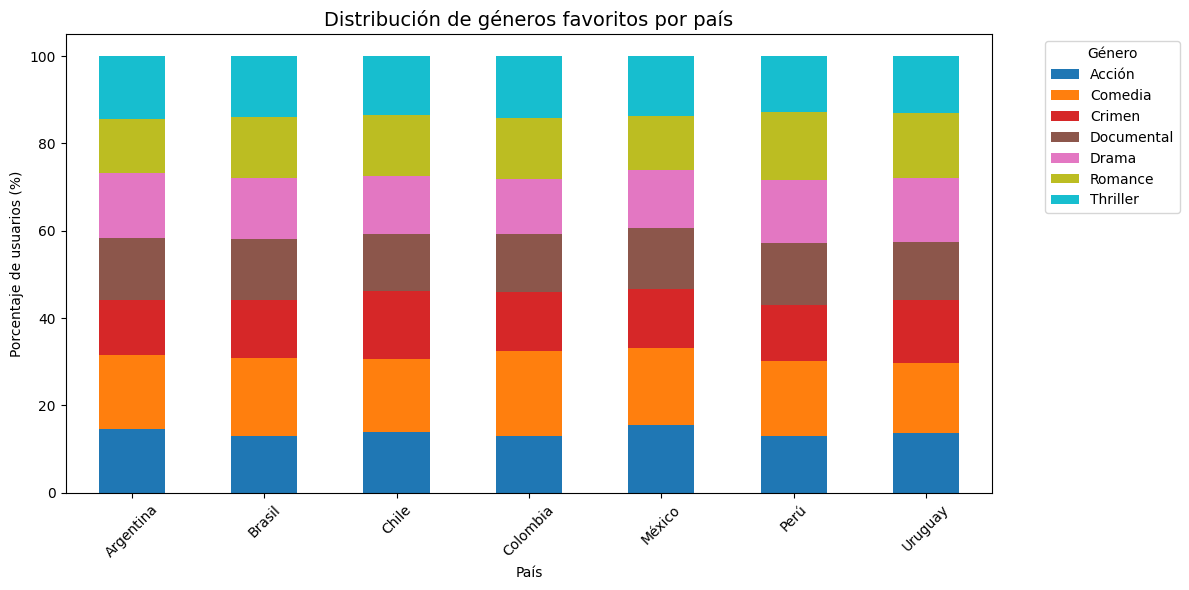

In [20]:
tabla = df.groupby(['country', 'favorite_genre']).size().unstack(fill_value=0)
tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 6))
tabla_pct.plot(kind='bar', stacked=True, colormap='tab10', figsize=(12, 6))
plt.title('Distribución de géneros favoritos por país', fontsize=14)
plt.xlabel('País')
plt.ylabel('Porcentaje de usuarios (%)')
plt.xticks(rotation=45)
plt.legend(title='Género', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

La distribución de géneros favoritos es bastante homogénea entre todos los países, sin preferencias culturales muy marcadas. En todos los casos los géneros se distribuyen de forma pareja alrededor del 14% cada uno. Se observa que Comedia tiene una presencia levemente mayor en la mayoría de los países, mientras que Documental tiende a ser el menos elegido. Esto sugiere que los gustos de los usuarios de la plataforma son similares independientemente del país de origen.

# **Análisis Multivariado**

El análisis multivariado estudia la relación entre más de dos variables simultáneamente.

#Pregunta #7 **¿La edad y el tiempo de visualización varían según el plan de suscripción?**

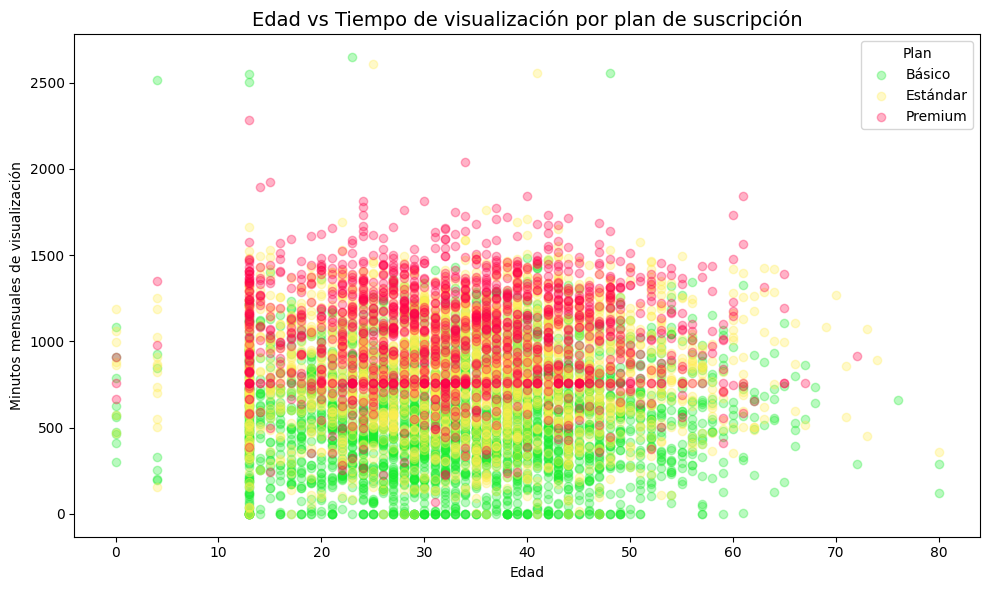

In [24]:
# Análisis multivariado: edad, tiempo de visualización y plan de suscripción

plt.figure(figsize=(10, 6))
colores_plan = {'Básico': '#18ed2d', 'Estándar': '#ffed4f', 'Premium': '#ff0048'}
for plan, grupo in df.groupby('subscription_plan'):
    plt.scatter(grupo['age'], grupo['monthly_watch_time_mins'],
                alpha=0.3, label=plan, color=colores_plan[plan])
plt.title('Edad vs Tiempo de visualización por plan de suscripción', fontsize=14)
plt.xlabel('Edad')
plt.ylabel('Minutos mensuales de visualización')
plt.legend(title='Plan')
plt.tight_layout()
plt.show()

Al incorporar el plan de suscripción como tercera variable, se confirma que la edad no determina el tiempo de visualización en ningún plan. Sin embargo, se observa claramente que los puntos rojos (Premium) se concentran en valores más altos del eje Y, mientras que los verdes (Básico) se concentran en valores más bajos, independientemente de la edad.

## Conclusiones del EDA

- El plan Básico concentra casi la mitad de los usuarios (44.75%), lo que indica una base de usuarios orientada a planes económicos.
- Los usuarios tienen en promedio 33 años, con mayor concentración entre los 25 y 45 años.
- Los géneros están distribuidos de forma pareja, siendo Comedia el más popular con 17.36%.
- Existe una relación clara entre el plan de suscripción y el tiempo de visualización: los usuarios Premium consumen casi el doble que los Básico.
- La edad no tiene influencia en el tiempo de visualización (correlación de 0.003).
- Los gustos por género son similares en todos los países analizados, sin preferencias culturales marcadas.
- Al analizar edad, tiempo de visualización y plan simultáneamente, se confirma que el plan de suscripción es el factor más determinante en el consumo de contenido, independientemente de la edad del usuario.